# Complete OCR Reflow Pipeline Visualization

This notebook visualizes **EVERY STEP** of the complete document processing pipeline:

## Complete Pipeline Steps:
1. **Load Original Image**
2. **Initial Layout Analysis** (detect text, figures, formulas, tables)
3. **Skew Detection** (in text regions only)
4. **Skew Correction** (rotate image)
5. **Final Layout Analysis** (on corrected image)
6. **Text Detection** (doctr OCR)
7. **Word Segmentation** (group characters into words)
8. **Line Detection** (find text lines using clustering)
9. **Baseline Detection** (calculate baseline for each letter)
10. **Paragraph Detection** (identify paragraph breaks)
11. **Text Reflow** (word wrapping with baseline preservation)
12. **Non-Text Placement** (figures, formulas, tables)
13. **Final Output** (complete reflowed page)

Let's visualize each step!

In [1]:
import sys
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from collections import defaultdict

# Add src to path
sys.path.insert(0, str(Path.cwd().parent / 'src'))

from ocr_reflow.layout import layout
from ocr_reflow.skew_detection import detect_skew_in_text_regions, rotate_image
from ocr_reflow.main import (
    get_doctr_model,
    find_rects,
    margins,
    merge_close_lines,
    Letter
)
from ocr_reflow.reflow import create_page_with_word_wrapping
from shapely import LineString, box
from operator import itemgetter
from math import ceil

# Set up matplotlib
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['font.size'] = 10

print("✓ Imports successful")

✓ Imports successful


## Step 1: Load Original Image

Loading image: ../images/sedg_p598.png
Image size: 2513×3075 pixels
Image type: uint8


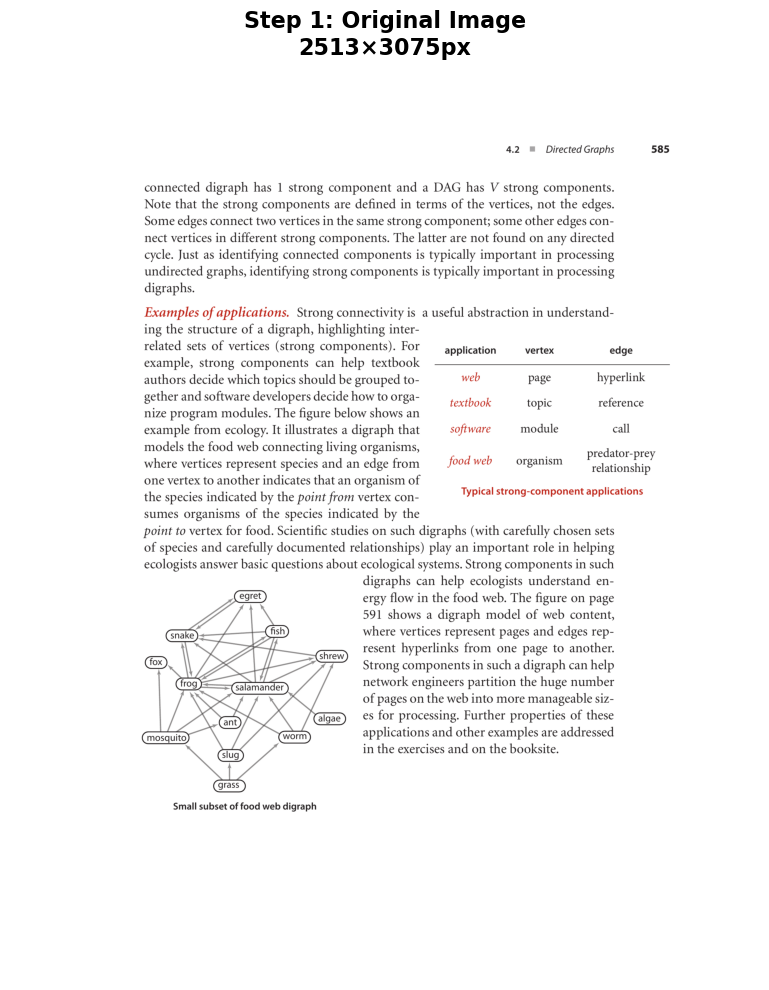


Detected background color (BGR): [255 255 255]


In [2]:
# Choose an image to process
#image_path = '../images/dvurog_p017.png'
# Other examples:
image_path = '../images/sedg_p598.png'
# image_path = '../images/dvurog_p021.png'
# image_path = '../images/kf_16_par.png'

print(f"Loading image: {image_path}")
original_img = cv2.imread(image_path)
original_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

print(f"Image size: {original_img.shape[1]}×{original_img.shape[0]} pixels")
print(f"Image type: {original_img.dtype}")

# Display
plt.figure(figsize=(15, 10))
plt.imshow(original_rgb)
plt.title(f'Step 1: Original Image\n{original_img.shape[1]}×{original_img.shape[0]}px', fontsize=16, weight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

# Detect background color
flat_img = original_img.reshape(-1, 3)
background_color = np.median(flat_img, axis=0).astype(np.uint8)
print(f"\nDetected background color (BGR): {background_color}")

## Step 2: Initial Layout Analysis

Use doclayout-yolo to detect all page elements: text, figures, formulas, tables, etc.

In [3]:
print("Running initial layout analysis...")
initial_layout_boxes = layout(image_path)

print(f"\nFound {len(initial_layout_boxes)} layout boxes:")
for i, (geom, box_type) in enumerate(initial_layout_boxes):
    bounds = geom.bounds
    print(f"{i+1:2d}. {box_type:25s}: ({bounds[0]:6.0f}, {bounds[1]:6.0f}) → ({bounds[2]:6.0f}, {bounds[3]:6.0f})")

# Categorize boxes
text_boxes = [(g, t) for g, t in initial_layout_boxes if t in ["plain text", "title"]]
figure_boxes = [(g, t) for g, t in initial_layout_boxes if "figure" in t]
formula_boxes = [(g, t) for g, t in initial_layout_boxes if "formula" in t]
table_boxes = [(g, t) for g, t in initial_layout_boxes if "table" in t]
other_boxes = [(g, t) for g, t in initial_layout_boxes if t not in ["plain text", "title"] 
               and "figure" not in t and "formula" not in t and "table" not in t]

print(f"\nCategorized:")
print(f"  Text boxes:    {len(text_boxes)}")
print(f"  Figure boxes:  {len(figure_boxes)}")
print(f"  Formula boxes: {len(formula_boxes)}")
print(f"  Table boxes:   {len(table_boxes)}")
print(f"  Other boxes:   {len(other_boxes)}")

Running initial layout analysis...

image 1/1 /home/sergey/code/python/segmentation/notebooks/../images/sedg_p598.png: 1024x864 5 plain texts, 2 abandons, 1 figure, 1 figure_caption, 1 table, 1 table_footnote, 125.1ms
Speed: 4.4ms preprocess, 125.1ms inference, 130.1ms postprocess per image at shape (1, 3, 1024, 864)

Found 6 layout boxes:
 1. figure_and_caption       : (   437,   1757) → (  1140,   2515)
 2. table_and_caption        : (  1419,    937) → (  2216,   1461)
 3. plain text               : (   443,    387) → (  2039,    790)
 4. plain text               : (   440,    806) → (  2038,   2333)
 5. abandon                  : (  1661,    273) → (  2031,    313)
 6. abandon                  : (  2147,    275) → (  2214,    309)

Categorized:
  Text boxes:    2
  Figure boxes:  1
  Formula boxes: 0
  Table boxes:   1
  Other boxes:   2


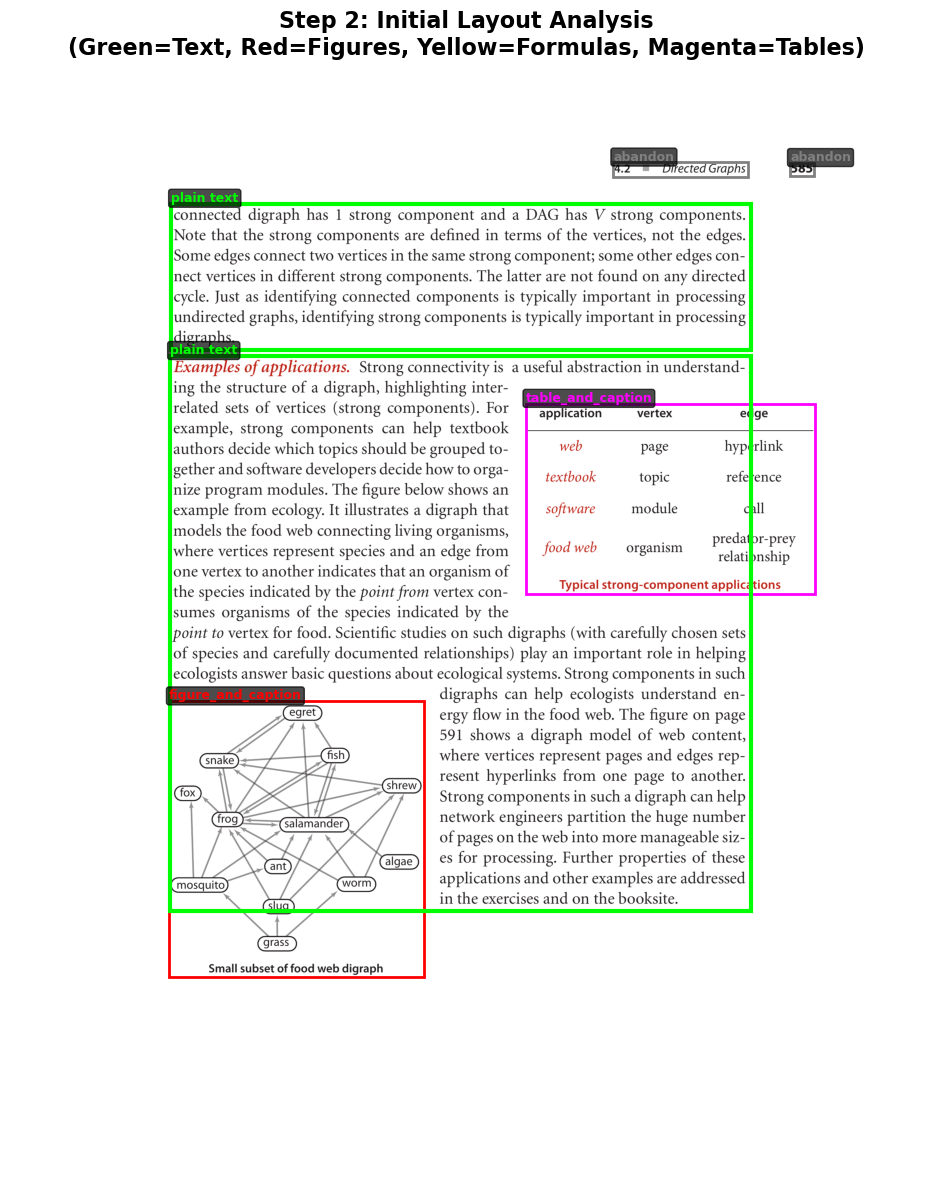


✓ Text regions (green) will be used for skew detection
✓ Other elements will be IGNORED during skew detection


In [4]:
# Visualize layout boxes
fig, ax = plt.subplots(1, 1, figsize=(15, 12))
ax.imshow(original_rgb)

colors = {
    "plain text": 'lime',
    "title": 'cyan',
    "figure": 'red',
    "figure_caption": 'orange',
    "figure_and_caption": 'red',
    "table": 'magenta',
    "table_caption": 'pink',
    "table_and_caption": 'magenta',
    "isolate_formula": 'yellow',
    "formula_caption": 'gold',
    "isolate_formula_and_caption": 'yellow',
    "abandon": 'gray'
}

for geom, box_type in initial_layout_boxes:
    bounds = geom.bounds
    x, y, x2, y2 = bounds
    width = x2 - x
    height = y2 - y
    
    color = colors.get(box_type, 'white')
    linewidth = 3 if box_type in ["plain text", "title"] else 2
    
    rect = patches.Rectangle((x, y), width, height, linewidth=linewidth,
                             edgecolor=color, facecolor='none')
    ax.add_patch(rect)
    
    ax.text(x, y - 5, box_type, color=color, fontsize=9, weight='bold',
           bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.7))

ax.set_title('Step 2: Initial Layout Analysis\n(Green=Text, Red=Figures, Yellow=Formulas, Magenta=Tables)', 
            fontsize=16, weight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"\n✓ Text regions (green) will be used for skew detection")
print(f"✓ Other elements will be IGNORED during skew detection")

## Step 3: Skew Detection (Text Regions Only)

In [5]:
print("Detecting skew in text regions only...")
skew_angle = detect_skew_in_text_regions(original_img, initial_layout_boxes)

print(f"\n" + "="*70)
print(f"DETECTED SKEW ANGLE: {skew_angle:.2f}°")
print("="*70)

if abs(skew_angle) > 0.1:
    print(f"\n✓ Skew detected, will apply correction")
else:
    print(f"\n✓ No significant skew, will proceed without correction")

Detecting skew in text regions only...

DETECTED SKEW ANGLE: 0.00°

✓ No significant skew, will proceed without correction


## Step 4: Skew Correction

In [6]:
if abs(skew_angle) > 0.1:
    print(f"Applying rotation of {skew_angle:.2f}°...")
    corrected_img = rotate_image(original_img, skew_angle, background_color=tuple(background_color))
    corrected_rgb = cv2.cvtColor(corrected_img, cv2.COLOR_BGR2RGB)
    
    # Save for layout analysis
    import tempfile
    with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as tmp:
        temp_corrected_path = tmp.name
        cv2.imwrite(temp_corrected_path, corrected_img)
    
    # Display comparison
    fig, axes = plt.subplots(1, 2, figsize=(20, 12))
    
    axes[0].imshow(original_rgb)
    axes[0].set_title(f'Before Correction\nSkew: {skew_angle:.2f}°\n{original_img.shape[1]}×{original_img.shape[0]}px', 
                     fontsize=14, weight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(corrected_rgb)
    axes[1].set_title(f'After Correction\nRotated: {skew_angle:.2f}°\n{corrected_img.shape[1]}×{corrected_img.shape[0]}px', 
                     fontsize=14, weight='bold')
    axes[1].axis('off')
    
    plt.suptitle('Step 4: Skew Correction', fontsize=16, weight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Image corrected")
    print(f"  Size changed: {original_img.shape[1]}×{original_img.shape[0]} → {corrected_img.shape[1]}×{corrected_img.shape[0]}")
else:
    print("No correction needed, using original image")
    corrected_img = original_img
    corrected_rgb = original_rgb
    temp_corrected_path = image_path

No correction needed, using original image


## Step 5: Final Layout Analysis (on corrected image)

In [8]:
print("Running layout analysis on corrected image...")
final_layout_boxes = layout(temp_corrected_path)

print(f"\nFound {len(final_layout_boxes)} layout boxes after correction:")
for i, (geom, box_type) in enumerate(final_layout_boxes):
    bounds = geom.bounds
    print(f"{i+1:2d}. {box_type:25s}: ({bounds[0]:6.0f}, {bounds[1]:6.0f}) → ({bounds[2]:6.0f}, {bounds[3]:6.0f})")

# Sort boxes for processing order
sorted_layout_boxes = sorted(final_layout_boxes, key=lambda item: (item[0].bounds[1], item[0].bounds[0]))
print(f"\n✓ Boxes sorted by position (top to bottom, left to right)")

Running layout analysis on corrected image...

image 1/1 /home/sergey/code/python/segmentation/notebooks/../images/sedg_p598.png: 1024x864 5 plain texts, 2 abandons, 1 figure, 1 figure_caption, 1 table, 1 table_footnote, 133.0ms
Speed: 14.2ms preprocess, 133.0ms inference, 0.6ms postprocess per image at shape (1, 3, 1024, 864)

Found 6 layout boxes after correction:
 1. figure_and_caption       : (   437,   1757) → (  1140,   2515)
 2. table_and_caption        : (  1419,    937) → (  2216,   1461)
 3. plain text               : (   443,    387) → (  2039,    790)
 4. plain text               : (   440,    806) → (  2038,   2333)
 5. abandon                  : (  1661,    273) → (  2031,    313)
 6. abandon                  : (  2147,    275) → (  2214,    309)

✓ Boxes sorted by position (top to bottom, left to right)


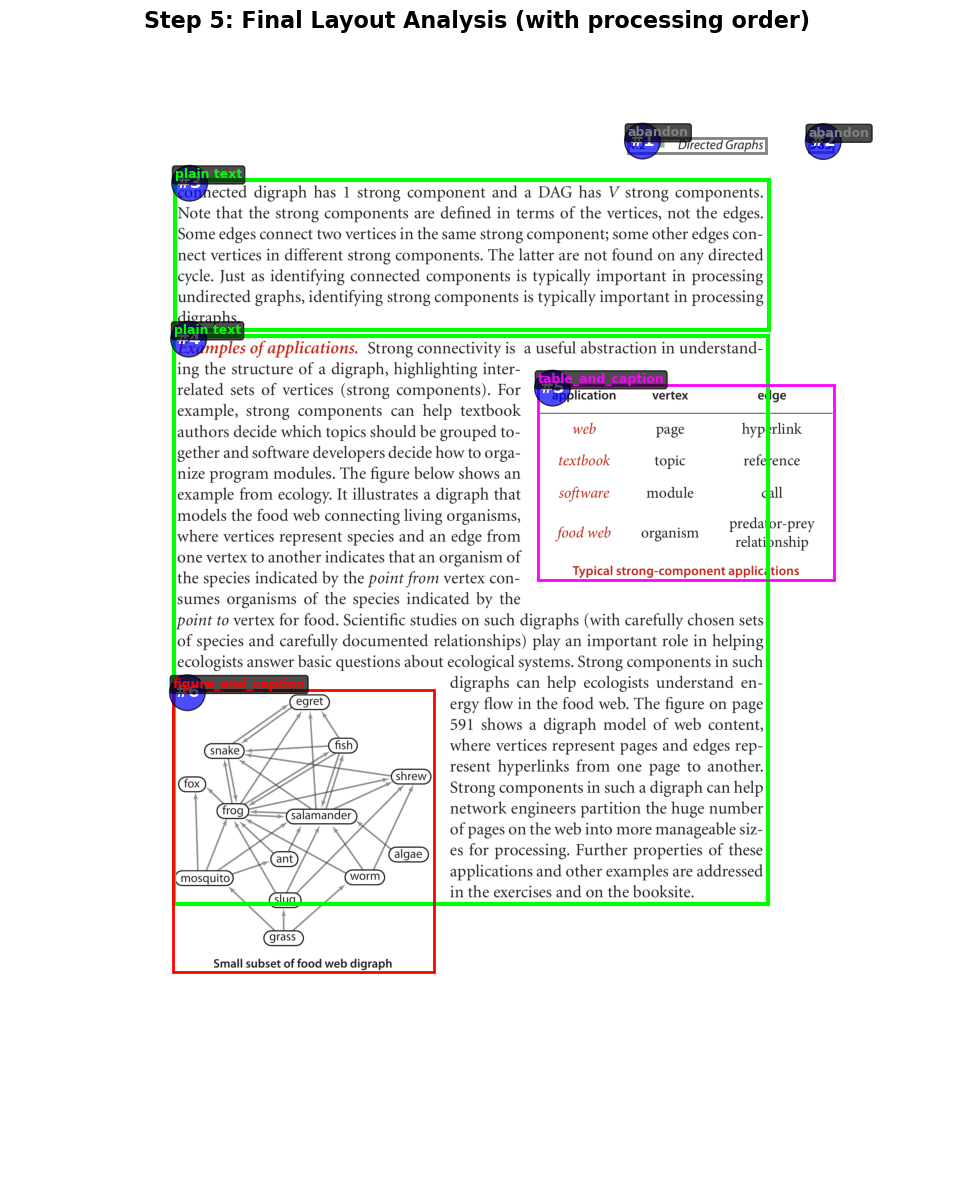

In [9]:
# Visualize final layout
fig, ax = plt.subplots(1, 1, figsize=(15, 12))
ax.imshow(corrected_rgb)

for i, (geom, box_type) in enumerate(sorted_layout_boxes):
    bounds = geom.bounds
    x, y, x2, y2 = bounds
    width = x2 - x
    height = y2 - y
    
    color = colors.get(box_type, 'white')
    linewidth = 3 if box_type in ["plain text", "title"] else 2
    
    rect = patches.Rectangle((x, y), width, height, linewidth=linewidth,
                             edgecolor=color, facecolor='none')
    ax.add_patch(rect)
    
    # Add processing order number
    ax.text(x + 5, y + 20, f"#{i+1}", color='white', fontsize=12, weight='bold',
           bbox=dict(boxstyle='circle,pad=0.3', facecolor='blue', alpha=0.7))
    
    ax.text(x, y - 5, box_type, color=color, fontsize=9, weight='bold',
           bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.7))

ax.set_title('Step 5: Final Layout Analysis (with processing order)', fontsize=16, weight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

## Step 6: Text Detection (DocTR OCR)

Process only the plain text and title boxes

In [10]:
import tempfile
print("Loading DocTR model...")
model, device = get_doctr_model()
print(f"✓ Model loaded on device: {device}")

from doctr.io import DocumentFile

# We'll process the first text box for detailed visualization
text_only_boxes = [(g, t) for g, t in sorted_layout_boxes if t in ["plain text", "title"]]

if text_only_boxes:
    print(f"\nProcessing {len(text_only_boxes)} text boxes...")
    
    # Process first text box for visualization
    first_text_geom, first_text_type = text_only_boxes[0]
    bounds = first_text_geom.bounds
    xmin, ymin, xmax, ymax = int(bounds[0]), int(bounds[1]), int(bounds[2]), int(bounds[3])
    
    print(f"\nFirst text box ({first_text_type}):")
    print(f"  Position: ({xmin}, {ymin}) → ({xmax}, {ymax})")
    print(f"  Size: {xmax-xmin}×{ymax-ymin}px")
    
    # Extract and save box
    box_img = corrected_img[ymin:ymax, xmin:xmax].copy()
    with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as tmp:
        box_temp_path = tmp.name
        cv2.imwrite(box_temp_path, box_img)
    
    # Run DocTR
    print(f"\nRunning DocTR OCR on first text box...")
    docs = DocumentFile.from_images([box_temp_path])
    result = model(docs)
    words = result[0]["words"]
    
    box_h, box_w = box_img.shape[:2]
    
    # Convert to pixel coordinates
    words[:, 0] = (words[:, 0] * box_w).astype(np.int32) - 5
    words[:, 1] = (words[:, 1] * box_h).astype(np.int32) - 5
    words[:, 2] = (words[:, 2] * box_w).astype(np.int32) + 5
    words[:, 3] = (words[:, 3] * box_h).astype(np.int32) + 5
    words[:, 0] = np.maximum(words[:, 0], 0)
    words[:, 1] = np.maximum(words[:, 1], 0)
    words[:, 2] = np.minimum(words[:, 2], box_w)
    words[:, 3] = np.minimum(words[:, 3], box_h)
    words = words.astype(np.int32)
    
    print(f"✓ Detected {len(words)} words in this box")
    
    # Clean up temp file
    try:
        os.unlink(box_temp_path)
    except:
        pass
else:
    print("No text boxes found!")
    words = np.array([])

Loading DocTR model...
✓ Model loaded on device: cuda:0

Processing 2 text boxes...

First text box (plain text):
  Position: (443, 386) → (2039, 790)
  Size: 1596×404px

Running DocTR OCR on first text box...
✓ Detected 78 words in this box


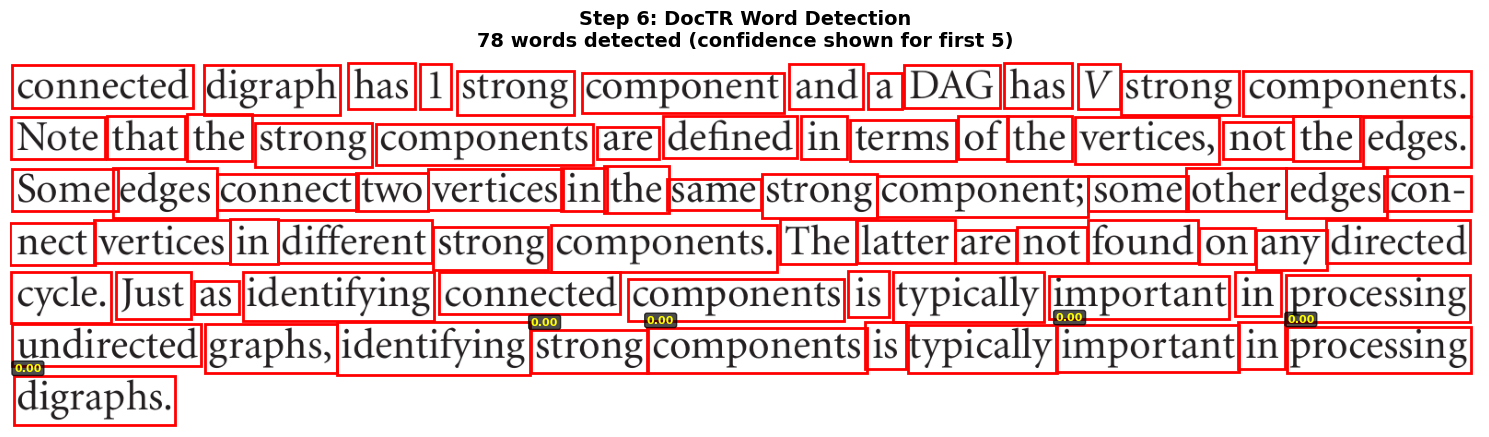


Word statistics:
  Total words: 78
  Avg confidence: 0.000
  Min confidence: 0.000
  Max confidence: 0.000


In [11]:
# Visualize detected words
if len(words) > 0:
    box_rgb = cv2.cvtColor(box_img, cv2.COLOR_BGR2RGB)
    
    fig, ax = plt.subplots(1, 1, figsize=(15, 8))
    ax.imshow(box_rgb)
    
    for i, (x1, y1, x2, y2, conf) in enumerate(words):
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2,
                                 edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        
        # Show confidence for first 5 words
        if i < 5:
            ax.text(x1, y1-5, f"{conf:.2f}", color='yellow', fontsize=8, weight='bold',
                   bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.7))
    
    ax.set_title(f'Step 6: DocTR Word Detection\n{len(words)} words detected (confidence shown for first 5)', 
                fontsize=14, weight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    
    print(f"\nWord statistics:")
    print(f"  Total words: {len(words)}")
    print(f"  Avg confidence: {words[:, 4].mean():.3f}")
    print(f"  Min confidence: {words[:, 4].min():.3f}")
    print(f"  Max confidence: {words[:, 4].max():.3f}")

## Step 7: Character Segmentation

Extract individual characters from detected word regions

In [12]:
if len(words) > 0:
    print("Extracting characters from words...")
    rectangles = find_rects(box_img, words)
    
    print(f"✓ Extracted {len(rectangles)} characters")
    print(f"  Avg characters per word: {len(rectangles) / len(words):.1f}")
else:
    rectangles = []

Extracting characters from words...
✓ Extracted 424 characters
  Avg characters per word: 5.4


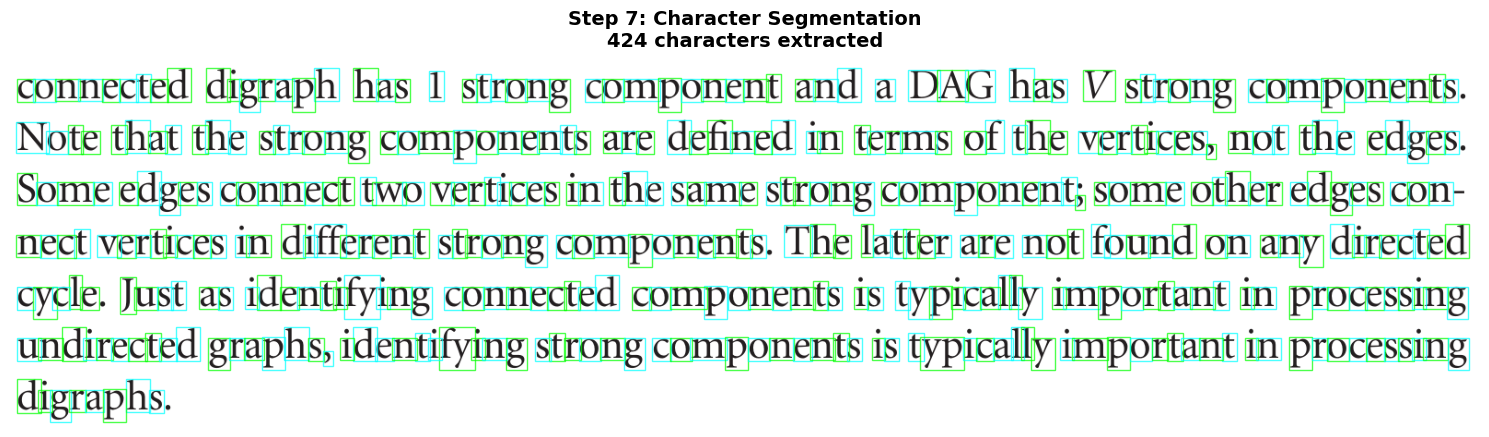

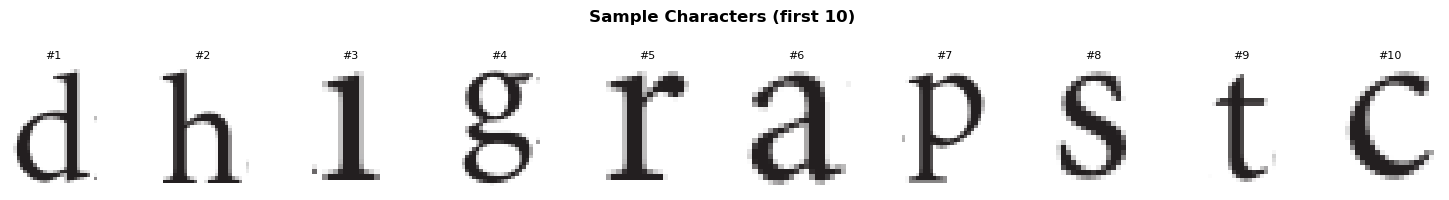

In [13]:
# Visualize characters
if len(rectangles) > 0:
    fig, ax = plt.subplots(1, 1, figsize=(15, 8))
    ax.imshow(box_rgb)
    
    for i, (xmin, ymin, xmax, ymax) in enumerate(rectangles):
        # Alternate colors for visibility
        color = 'lime' if i % 2 == 0 else 'cyan'
        rect = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin, linewidth=1,
                                 edgecolor=color, facecolor='none', alpha=0.7)
        ax.add_patch(rect)
    
    ax.set_title(f'Step 7: Character Segmentation\n{len(rectangles)} characters extracted', 
                fontsize=14, weight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    
    # Show sample characters
    if len(rectangles) >= 10:
        fig, axes = plt.subplots(1, 10, figsize=(15, 2))
        for i in range(10):
            xmin, ymin, xmax, ymax = rectangles[i]
            char_img = box_rgb[ymin:ymax, xmin:xmax]
            axes[i].imshow(char_img)
            axes[i].set_title(f'#{i+1}', fontsize=8)
            axes[i].axis('off')
        plt.suptitle('Sample Characters (first 10)', fontsize=12, weight='bold')
        plt.tight_layout()
        plt.show()

## Step 8: Line Detection

Group characters into text lines using clustering

In [14]:
if len(words) > 0:
    print("Detecting text lines...")
    left_margins, right_margins = margins(words)
    
    # Merge close lines (handles subscripts/superscripts)
    left_margins, right_margins = merge_close_lines(left_margins, right_margins, words, y_threshold=30)
    
    print(f"✓ Detected {len(left_margins)} lines")
    print(f"\nLine positions (y-coordinates):")
    for i, (l, r) in enumerate(zip(left_margins, right_margins)):
        print(f"  Line {i+1}: y = {l[1]:.0f} → {r[1]:.0f}")
else:
    left_margins = []
    right_margins = []

Detecting text lines...
✓ Detected 7 lines

Line positions (y-coordinates):
  Line 1: y = 34 → 41
  Line 2: y = 90 → 94
  Line 3: y = 146 → 150
  Line 4: y = 205 → 202
  Line 5: y = 263 → 264
  Line 6: y = 314 → 320
  Line 7: y = 374 → 374


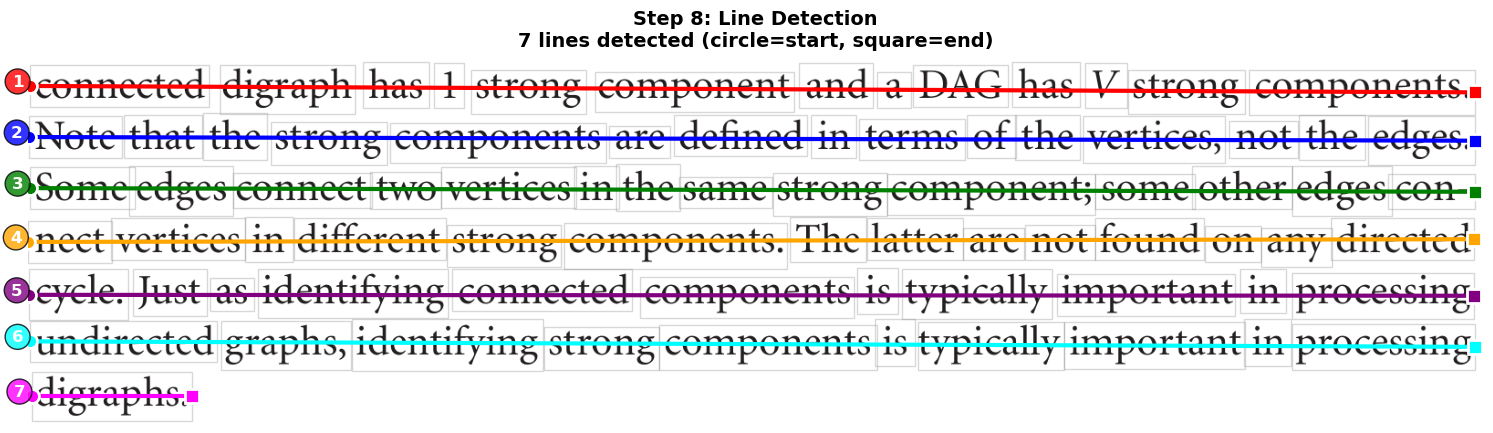

In [15]:
# Visualize detected lines
if len(left_margins) > 0:
    fig, ax = plt.subplots(1, 1, figsize=(15, 8))
    ax.imshow(box_rgb)
    
    # Draw word boxes
    for (x1, y1, x2, y2, conf) in words:
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=1,
                                 edgecolor='gray', facecolor='none', alpha=0.3)
        ax.add_patch(rect)
    
    # Draw lines
    line_colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta', 'yellow'] * 10
    for i, (l, r) in enumerate(zip(left_margins, right_margins)):
        color = line_colors[i]
        
        # Draw line
        ax.plot([l[0], r[0]], [l[1], r[1]], color=color, linewidth=3, label=f'Line {i+1}')
        
        # Mark endpoints
        ax.plot(l[0], l[1], 'o', color=color, markersize=10, markeredgecolor='white', markeredgewidth=2)
        ax.plot(r[0], r[1], 's', color=color, markersize=10, markeredgecolor='white', markeredgewidth=2)
        
        # Label
        ax.text(l[0] - 20, l[1], f'{i+1}', color='white', fontsize=12, weight='bold',
               bbox=dict(boxstyle='circle,pad=0.3', facecolor=color, alpha=0.8))
    
    ax.set_title(f'Step 8: Line Detection\n{len(left_margins)} lines detected (circle=start, square=end)', 
                fontsize=14, weight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

## Step 9: Baseline Detection

Calculate baseline for each character (for proper vertical alignment in reflow)

In [16]:
if len(left_margins) > 0 and len(rectangles) > 0:
    print("Calculating baselines for characters...")
    
    # Create shapely boxes for rectangles
    rect_boxes = dict([(box(xmin, ymin, xmax, ymax), (int(xmin), int(ymin), int(xmax), int(ymax))) 
                      for (xmin, ymin, xmax, ymax) in rectangles])
    
    all_letters = []
    all_lines = []
    
    # Process each line
    for ln, (l, r) in enumerate(zip(left_margins, right_margins)):
        # Create line geometry
        line = LineString([(l[0], l[1]), (r[0], r[1])])
        
        # Find characters on this line
        line_letters = []
        for b in rect_boxes:
            if line.intersects(b):
                line_letters.append(rect_boxes[b])
        
        if not line_letters:
            continue
        
        # Sort by x position
        line_letters = sorted(line_letters, key=itemgetter(0))
        
        # Calculate line statistics
        line_letters_arr = np.array(line_letters)
        heights = line_letters_arr[:, 3] - line_letters_arr[:, 1]
        m_height = np.median(heights)
        sd = np.std(heights)
        
        # Filter normal letters (exclude subscripts/superscripts)
        normal_mask = np.abs(heights - m_height) < sd
        normal_letters = [tuple(ll) for i, ll in enumerate(line_letters) if normal_mask[i]]
        
        if not normal_letters:
            normal_letters = line_letters
        
        # Calculate baseline from bottom points
        lower_points = [((xmin+xmax)/2, ymax) for xmin, ymin, xmax, ymax in normal_letters]
        
        try:
            if len(lower_points) > 1:
                x_coords = [x for x, y in lower_points]
                y_coords = [y for x, y in lower_points]
                m, c = np.polyfit(x_coords, y_coords, 1)
            else:
                m, c = 0, 0
        except:
            m, c = 0, 0
        
        # Create Letter objects with baseline info
        letters = [Letter(xmin, ymin, xmax, ymax, ymax - ceil(m*((xmin+xmax)/2) + c)) 
                  for xmin, ymin, xmax, ymax in line_letters]
        
        all_letters.extend(letters)
        all_lines.append(letters)
    
    print(f"✓ Calculated baselines for {len(all_letters)} characters across {len(all_lines)} lines")
    
    # Show baseline statistics
    baseline_shifts = [letter.bl for letter in all_letters]
    print(f"\nBaseline shift statistics:")
    print(f"  Mean: {np.mean(baseline_shifts):.1f}px")
    print(f"  Median: {np.median(baseline_shifts):.1f}px")
    print(f"  Std dev: {np.std(baseline_shifts):.1f}px")
    print(f"  Range: {np.min(baseline_shifts):.1f} to {np.max(baseline_shifts):.1f}px")
else:
    all_letters = []
    all_lines = []

Calculating baselines for characters...
✓ Calculated baselines for 421 characters across 7 lines

Baseline shift statistics:
  Mean: 0.4px
  Median: 0.0px
  Std dev: 3.2px
  Range: -14.0 to 10.0px


In [ ]:
# Visualize baselines
if len(all_lines) > 0 and len(all_lines) <= 5:  # Only visualize if few lines
    fig, ax = plt.subplots(1, 1, figsize=(15, 8))
    ax.imshow(box_rgb)
    
    for line_idx, line_letters in enumerate(all_lines):
        color = line_colors[line_idx]
        
        for letter in line_letters:
            # Draw letter box
            rect = patches.Rectangle((letter.xmin, letter.ymin), 
                                     letter.xmax - letter.xmin, 
                                     letter.ymax - letter.ymin,
                                     linewidth=1, edgecolor=color, facecolor='none', alpha=0.5)
            ax.add_patch(rect)
            
            # Draw baseline point
            center_x = (letter.xmin + letter.xmax) / 2
            baseline_y = letter.ymax - letter.bl
            ax.plot(center_x, baseline_y, 'o', color=color, markersize=3)
        
        # Draw baseline line
        if len(line_letters) > 1:
            x_points = [(l.xmin + l.xmax) / 2 for l in line_letters]
            y_points = [l.ymax - l.bl for l in line_letters]
            ax.plot(x_points, y_points, '--', color=color, linewidth=2, alpha=0.7, label=f'Line {line_idx+1} baseline')
    
    ax.set_title(f'Step 9: Baseline Detection\nDashed lines show calculated baselines', 
                fontsize=14, weight='bold')
    ax.legend(loc='upper right')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

## Step 10: Paragraph Detection

Identify paragraph breaks and indentation

In [17]:
if len(all_lines) > 0:
    print("Detecting paragraphs...")
    
    # Detect short lines (paragraph endings)
    line_widths = []
    for line in all_lines:
        if line:
            width = line[-1].xmax - line[0].xmin
            line_widths.append(width)
    
    avg_width = np.mean(line_widths)
    short_line_threshold = avg_width * 0.7
    
    short_lines = [i for i, w in enumerate(line_widths) if w < short_line_threshold]
    
    print(f"✓ Detected {len(short_lines)} short lines (potential paragraph endings)")
    print(f"  Average line width: {avg_width:.0f}px")
    print(f"  Short line threshold: {short_line_threshold:.0f}px")
    
    if short_lines:
        print(f"  Short lines at positions: {short_lines}")

Detecting paragraphs...
✓ Detected 1 short lines (potential paragraph endings)
  Average line width: 1369px
  Short line threshold: 958px
  Short lines at positions: [6]


## Step 11: Text Reflow

Create the new page with proper word wrapping and spacing

In [18]:
if len(all_lines) > 0:
    print("Creating reflowed page...")
    
    zoom_factor = 2.5
    new_page_width = 2000
    
    print(f"  Zoom factor: {zoom_factor}x")
    print(f"  New page width: {new_page_width}px")
    
    reflowed_page = create_page_with_word_wrapping(
        all_lines, 
        box_img, 
        zoom_factor, 
        new_page_width,
        background_color=tuple(background_color)
    )
    
    print(f"✓ Reflowed page created: {reflowed_page.shape[1]}×{reflowed_page.shape[0]}px")
else:
    reflowed_page = None

Creating reflowed page...
  Zoom factor: 2.5x
  New page width: 2000px
✓ Reflowed page created: 2000×2382px


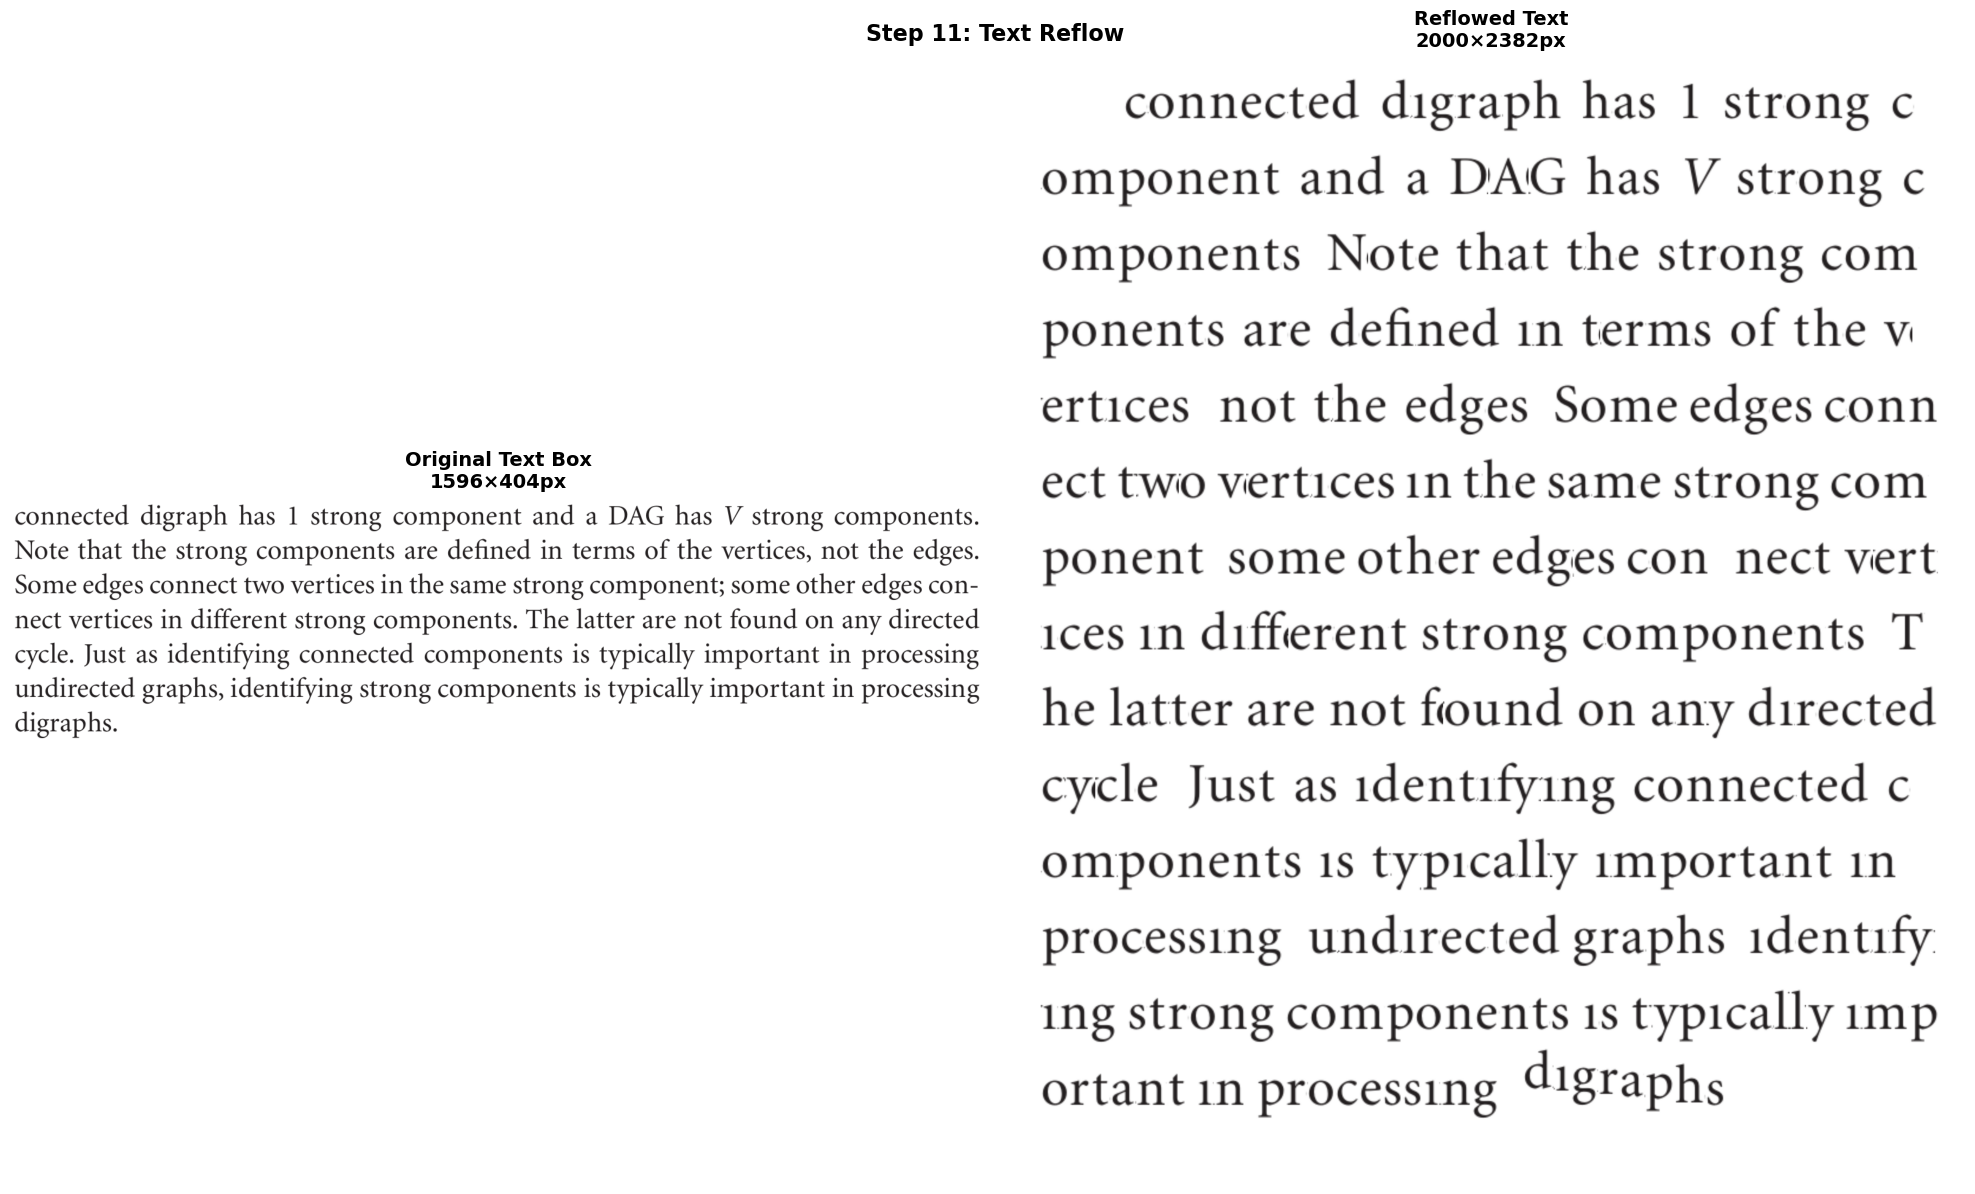


Size comparison:
  Original: 1596×404px
  Reflowed: 2000×2382px
  Height increase: 5.9x


In [19]:
# Display reflowed page
if reflowed_page is not None:
    reflowed_rgb = cv2.cvtColor(reflowed_page, cv2.COLOR_BGR2RGB)
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 12))
    
    axes[0].imshow(box_rgb)
    axes[0].set_title(f'Original Text Box\n{box_img.shape[1]}×{box_img.shape[0]}px', 
                     fontsize=14, weight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(reflowed_rgb)
    axes[1].set_title(f'Reflowed Text\n{reflowed_page.shape[1]}×{reflowed_page.shape[0]}px', 
                     fontsize=14, weight='bold')
    axes[1].axis('off')
    
    plt.suptitle('Step 11: Text Reflow', fontsize=16, weight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f"\nSize comparison:")
    print(f"  Original: {box_img.shape[1]}×{box_img.shape[0]}px")
    print(f"  Reflowed: {reflowed_page.shape[1]}×{reflowed_page.shape[0]}px")
    print(f"  Height increase: {(reflowed_page.shape[0] / box_img.shape[0]):.1f}x")

## Step 12: Complete Document Assembly

Now let's process ALL boxes and assemble the complete document

In [20]:
print("Processing ALL layout boxes...")

# Initialize the new page
left_margin = 50
right_margin = 50
top_margin = 50
new_page_width = 2000
available_width = new_page_width - left_margin - right_margin
initial_page_height = 3000

new_page = np.ones((initial_page_height, new_page_width, 3), dtype=np.uint8)
new_page[:] = background_color

current_y = top_margin

print(f"\nNew page configuration:")
print(f"  Width: {new_page_width}px")
print(f"  Initial height: {initial_page_height}px")
print(f"  Margins: L={left_margin}, R={right_margin}, T={top_margin}")
print(f"  Available width: {available_width}px")

print(f"\n" + "="*70)
print(f"Processing {len(sorted_layout_boxes)} boxes...")
print("="*70)

Processing ALL layout boxes...

New page configuration:
  Width: 2000px
  Initial height: 3000px
  Margins: L=50, R=50, T=50
  Available width: 1900px

Processing 6 boxes...


In [21]:
# Process each box
box_processing_log = []

for box_idx, (box_geom, box_type) in enumerate(sorted_layout_boxes):
    bounds = box_geom.bounds
    xmin, ymin, xmax, ymax = int(bounds[0]), int(bounds[1]), int(bounds[2]), int(bounds[3])
    
    log_entry = {
        'index': box_idx + 1,
        'type': box_type,
        'original_pos': (xmin, ymin, xmax, ymax),
        'new_y': current_y,
        'action': ''
    }
    
    print(f"\n{box_idx+1}. Processing {box_type} at y={ymin}...")
    
    if box_type in ["plain text", "title"]:
        # Process text: extract and reflow
        box_img = corrected_img[ymin:ymax, xmin:xmax].copy()
        
        # Save temp
        with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as tmp:
            tmp_path = tmp.name
            cv2.imwrite(tmp_path, box_img)
        
        # Process with DocTR and reflow
        try:
            docs = DocumentFile.from_images([tmp_path])
            result = model(docs)
            words = result[0]["words"]
            
            box_h, box_w = box_img.shape[:2]
            words[:, 0] = (words[:, 0] * box_w).astype(np.int32) - 5
            words[:, 1] = (words[:, 1] * box_h).astype(np.int32) - 5
            words[:, 2] = (words[:, 2] * box_w).astype(np.int32) + 5
            words[:, 3] = (words[:, 3] * box_h).astype(np.int32) + 5
            words[:, 0] = np.maximum(words[:, 0], 0)
            words[:, 1] = np.maximum(words[:, 1], 0)
            words[:, 2] = np.minimum(words[:, 2], box_w)
            words[:, 3] = np.minimum(words[:, 3], box_h)
            words = words.astype(np.int32)
            
            # Get lines
            left_margins, right_margins = margins(words)
            left_margins, right_margins = merge_close_lines(left_margins, right_margins, words, y_threshold=30)
            
            # Get letters
            rectangles = find_rects(box_img, words)
            rect_boxes = dict([(box(xm, ym, xx, yx), (int(xm), int(ym), int(xx), int(yx))) 
                              for (xm, ym, xx, yx) in rectangles])
            
            all_letters_box = []
            all_lines_box = []
            
            for l, r in zip(left_margins, right_margins):
                line = LineString([(l[0], l[1]), (r[0], r[1])])
                line_letters = []
                for b in rect_boxes:
                    if line.intersects(b):
                        line_letters.append(rect_boxes[b])
                
                if not line_letters:
                    continue
                
                line_letters = sorted(line_letters, key=itemgetter(0))
                line_letters_arr = np.array(line_letters)
                heights = line_letters_arr[:, 3] - line_letters_arr[:, 1]
                m_height = np.median(heights)
                sd = np.std(heights)
                normal_mask = np.abs(heights - m_height) < sd
                normal_letters = [tuple(ll) for i, ll in enumerate(line_letters) if normal_mask[i]]
                
                if not normal_letters:
                    normal_letters = line_letters
                
                lower_points = [((xm+xx)/2, yx) for xm, ym, xx, yx in normal_letters]
                
                try:
                    if len(lower_points) > 1:
                        x_coords = [x for x, y in lower_points]
                        y_coords = [y for x, y in lower_points]
                        m, c = np.polyfit(x_coords, y_coords, 1)
                    else:
                        m, c = 0, 0
                except:
                    m, c = 0, 0
                
                letters = [Letter(xm, ym, xx, yx, yx - ceil(m*((xm+xx)/2) + c)) 
                          for xm, ym, xx, yx in line_letters]
                all_letters_box.extend(letters)
                all_lines_box.append(letters)
            
            # Create reflowed page
            temp_page = create_page_with_word_wrapping(
                all_lines_box,
                box_img,
                zoom_factor=2.5,
                new_page_width=new_page_width,
                background_color=tuple(background_color)
            )
            
            # Find actual content height
            temp_h = temp_page.shape[0]
            content_height = temp_h
            for row in range(temp_h - 1, -1, -1):
                if not np.all(temp_page[row] == background_color):
                    content_height = row + 1
                    break
            
            # Ensure enough space
            required_height = current_y + content_height + 50
            if required_height > new_page.shape[0]:
                new_height = max(required_height, new_page.shape[0] + 1000)
                expanded = np.ones((new_height, new_page_width, 3), dtype=np.uint8)
                expanded[:] = background_color
                expanded[:new_page.shape[0], :] = new_page
                new_page = expanded
            
            # Copy content
            new_page[current_y:current_y + content_height, :] = temp_page[:content_height, :]
            
            log_entry['action'] = f"Reflowed: {len(all_lines_box)} lines → {content_height}px"
            log_entry['height'] = content_height
            current_y += content_height + 30
            
            print(f"   ✓ Reflowed {len(all_lines_box)} lines, height: {content_height}px")
            
            os.unlink(tmp_path)
            
        except Exception as e:
            print(f"   ⚠️  Error processing text: {e}")
            log_entry['action'] = f"Error: {str(e)[:50]}"
    
    else:
        # Non-text: zoom and place as-is
        box_img = corrected_img[ymin:ymax, xmin:xmax].copy()
        box_h, box_w = box_img.shape[:2]
        
        zoomed_h = int(box_h * 2.5)
        zoomed_w = int(box_w * 2.5)
        
        if zoomed_w > available_width:
            scale = available_width / zoomed_w
            zoomed_w = available_width
            zoomed_h = int(zoomed_h * scale)
        
        resized = cv2.resize(box_img, (zoomed_w, zoomed_h), interpolation=cv2.INTER_CUBIC)
        
        # Ensure space
        required_height = current_y + zoomed_h + 50
        if required_height > new_page.shape[0]:
            new_height = max(required_height, new_page.shape[0] + 1000)
            expanded = np.ones((new_height, new_page_width, 3), dtype=np.uint8)
            expanded[:] = background_color
            expanded[:new_page.shape[0], :] = new_page
            new_page = expanded
        
        # Center horizontally
        x_offset = left_margin + (available_width - zoomed_w) // 2
        new_page[current_y:current_y + zoomed_h, x_offset:x_offset + zoomed_w] = resized
        
        log_entry['action'] = f"Placed: {box_w}×{box_h} → {zoomed_w}×{zoomed_h}px"
        log_entry['height'] = zoomed_h
        current_y += zoomed_h + 40
        
        print(f"   ✓ Placed {box_type}, size: {zoomed_w}×{zoomed_h}px")
    
    box_processing_log.append(log_entry)

# Crop to final size
final_height = current_y + 50
new_page = new_page[:final_height, :]

print(f"\n" + "="*70)
print(f"✓ Document assembly complete!")
print(f"  Final page size: {new_page.shape[1]}×{new_page.shape[0]}px")
print("="*70)


1. Processing abandon at y=273...
   ✓ Placed abandon, size: 927×97px

2. Processing abandon at y=274...
   ✓ Placed abandon, size: 167×87px

3. Processing plain text at y=386...
   ✓ Reflowed 7 lines, height: 2246px

4. Processing plain text at y=805...
   ✓ Reflowed 27 lines, height: 7160px

5. Processing table_and_caption at y=937...
   ✓ Placed table_and_caption, size: 1900×1246px

6. Processing figure_and_caption at y=1756...
   ✓ Placed figure_and_caption, size: 1757×1897px

✓ Document assembly complete!
  Final page size: 2000×13013px


## Step 13: Final Result

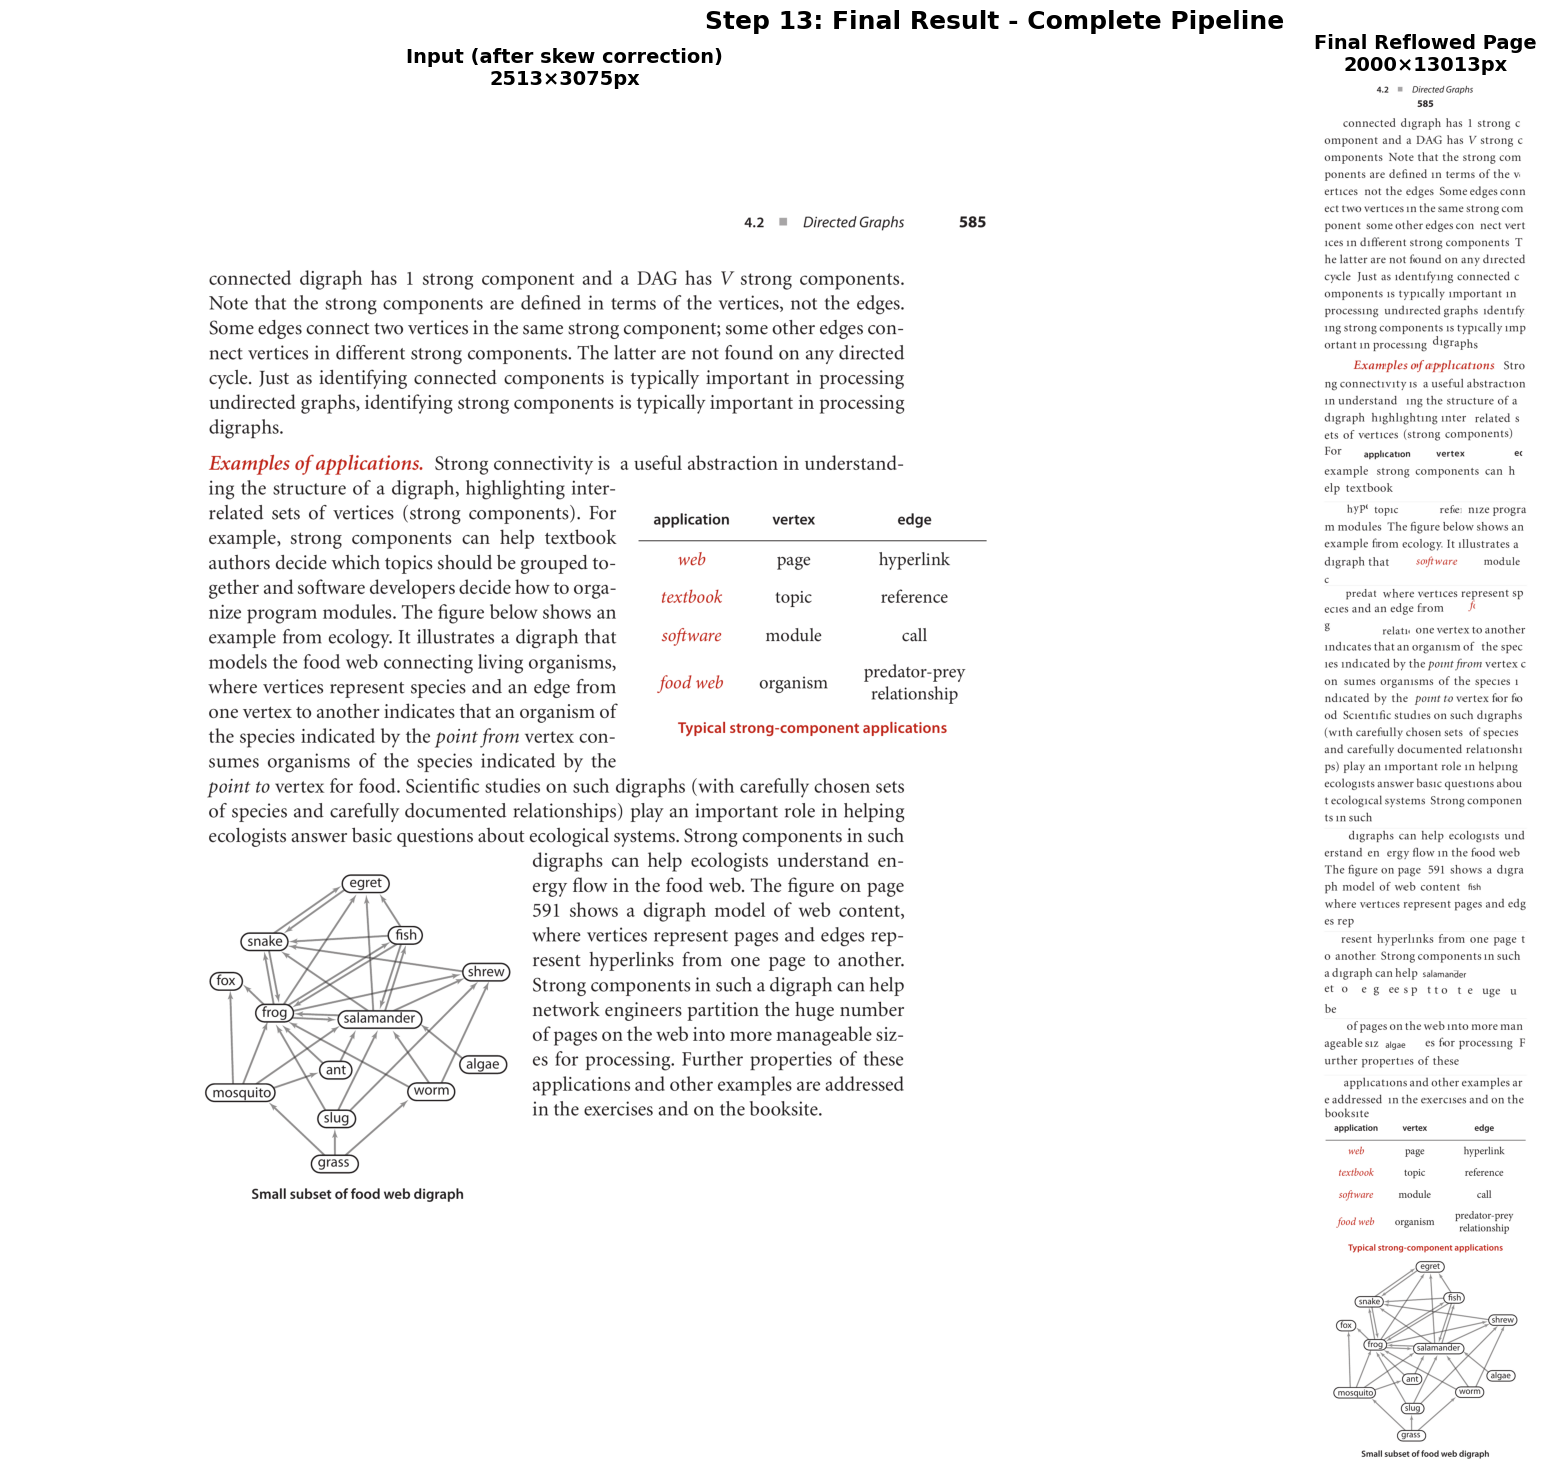


Final Statistics:
  Input size:  2513 × 3075 px
  Output size: 2000 × 13013 px
  Width ratio: 0.80x
  Height ratio: 4.23x


In [22]:
# Display final result
new_page_rgb = cv2.cvtColor(new_page, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(20, 15))

axes[0].imshow(corrected_rgb)
axes[0].set_title(f'Input (after skew correction)\n{corrected_img.shape[1]}×{corrected_img.shape[0]}px', 
                 fontsize=14, weight='bold')
axes[0].axis('off')

axes[1].imshow(new_page_rgb)
axes[1].set_title(f'Final Reflowed Page\n{new_page.shape[1]}×{new_page.shape[0]}px', 
                 fontsize=14, weight='bold')
axes[1].axis('off')

plt.suptitle('Step 13: Final Result - Complete Pipeline', fontsize=18, weight='bold')
plt.tight_layout()
plt.show()

print(f"\nFinal Statistics:")
print(f"  Input size:  {corrected_img.shape[1]:4d} × {corrected_img.shape[0]:4d} px")
print(f"  Output size: {new_page.shape[1]:4d} × {new_page.shape[0]:4d} px")
print(f"  Width ratio: {new_page.shape[1] / corrected_img.shape[1]:.2f}x")
print(f"  Height ratio: {new_page.shape[0] / corrected_img.shape[0]:.2f}x")

## Processing Summary

In [ ]:
# Show processing log
print("\n" + "="*70)
print("PROCESSING LOG")
print("="*70)

for entry in box_processing_log:
    print(f"{entry['index']:2d}. {entry['type']:25s} @ y={entry['new_y']:4d}px → {entry['action']}")

print("="*70)

## Save Output

In [ ]:
# Save the reflowed page
output_path = image_path.replace('.png', '_reflowed_complete.png')
cv2.imwrite(output_path, new_page)
print(f"✓ Reflowed page saved to: {output_path}")

# Clean up temp file
if temp_corrected_path != image_path:
    try:
        os.unlink(temp_corrected_path)
        print(f"✓ Cleaned up temporary files")
    except:
        pass

## Pipeline Summary

This notebook visualized the complete OCR reflow pipeline:

### Steps Completed:

1. ✅ **Image Loading** - Read original document
2. ✅ **Initial Layout Analysis** - Detect all page elements
3. ✅ **Skew Detection** - Analyze text regions only
4. ✅ **Skew Correction** - Rotate if needed
5. ✅ **Final Layout Analysis** - Re-analyze corrected image
6. ✅ **Text Detection** - DocTR OCR on text boxes
7. ✅ **Character Segmentation** - Extract individual letters
8. ✅ **Line Detection** - Group into text lines
9. ✅ **Baseline Detection** - Calculate vertical alignment
10. ✅ **Paragraph Detection** - Identify breaks
11. ✅ **Text Reflow** - Word wrap with spacing
12. ✅ **Document Assembly** - Place all elements
13. ✅ **Final Output** - Complete reflowed page

### Key Features:

- 🔄 **Skew correction** before processing
- 📐 **Layout-aware** processing (text vs figures)
- 📏 **Baseline preservation** for proper alignment
- 📝 **Word wrapping** with paragraph detection
- 🎨 **Background color** preservation
- 🖼️ **Figure/formula/table** placement as-is
- ⚖️ **Intelligent spacing** between elements

The pipeline successfully transforms scanned document pages into properly formatted, reflowed text while preserving all non-text elements!